In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [8]:
data = sns.load_dataset('titanic')
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [9]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [26]:
data.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

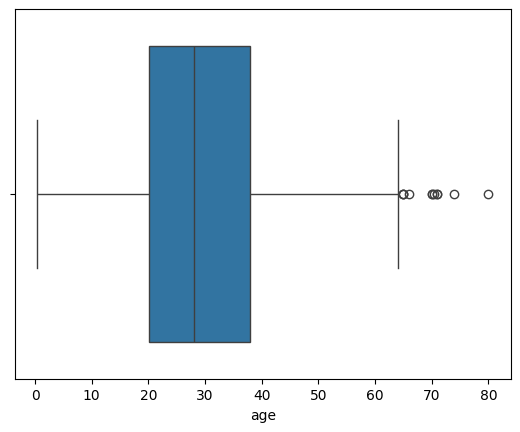

In [14]:
sns.boxplot(x=data['age'])
plt.show()

In [15]:
data['age'].fillna(data['age'].median(),inplace=True)

C:\Users\solan\AppData\Local\Temp\ipykernel_9584\3768969743.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].median(),inplace=True)


In [18]:
data['embark_town'].fillna(data['embark_town'].mode()[0],inplace=True)

In [20]:
(data['deck'].isnull().sum() / len(data)) * 100

np.float64(77.21661054994388)

In [21]:
data.drop(columns=['deck'],inplace=True)

In [25]:
data['embarked'].fillna(data['embarked'].mode()[0],inplace=True)

C:\Users\solan\AppData\Local\Temp\ipykernel_9584\3921951816.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  classes = sns.countplot(x='class',data=data,color = 'red',palette='husl')#set1,pastel,husl,coolwarm


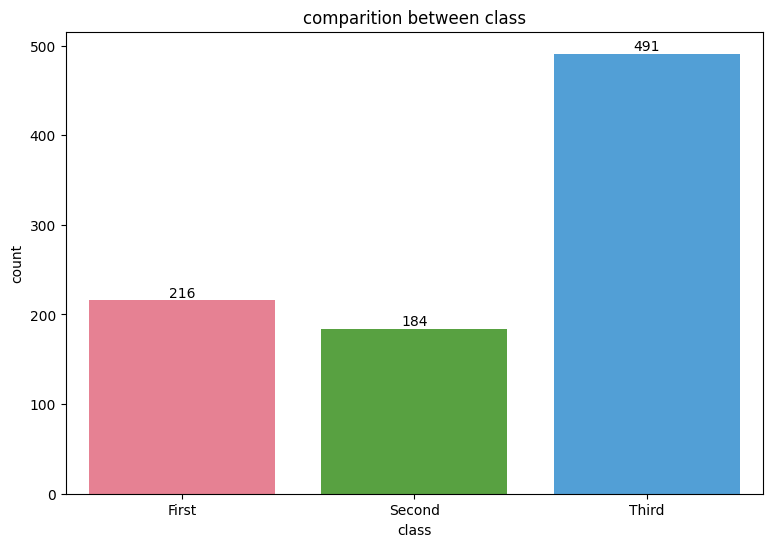

In [ ]:
plt.figure(figsize=(9,6))
classes = sns.countplot(x='class',data=data,color = 'red',palette='husl')#set1,pastel,husl,coolwarm
plt.title("comparition between class")
for count in classes.containers:
    classes.bar_label(count)
plt.show()

C:\Users\solan\AppData\Local\Temp\ipykernel_9584\3618695591.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  gender = sns.countplot(x='who',data=data,palette='Set1')


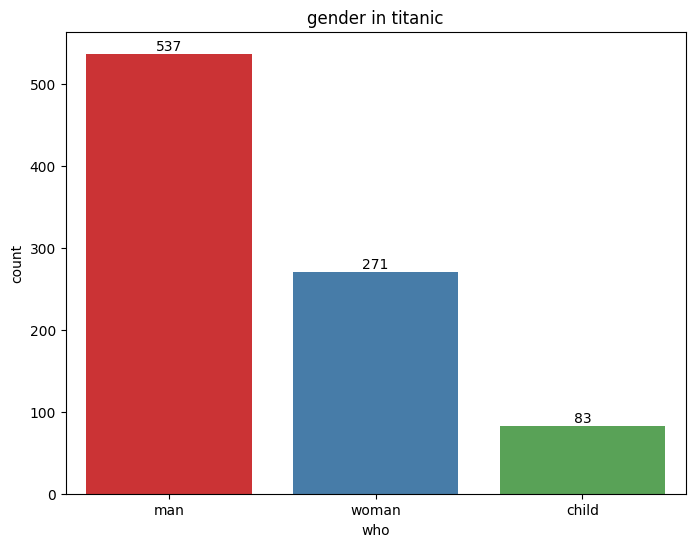

In [63]:
plt.figure(figsize=(8,6))
gender = sns.countplot(x='who',data=data,palette='Set1')
plt.title("gender in titanic")
for count in gender.containers:
    gender.bar_label(count)
    
plt.show()

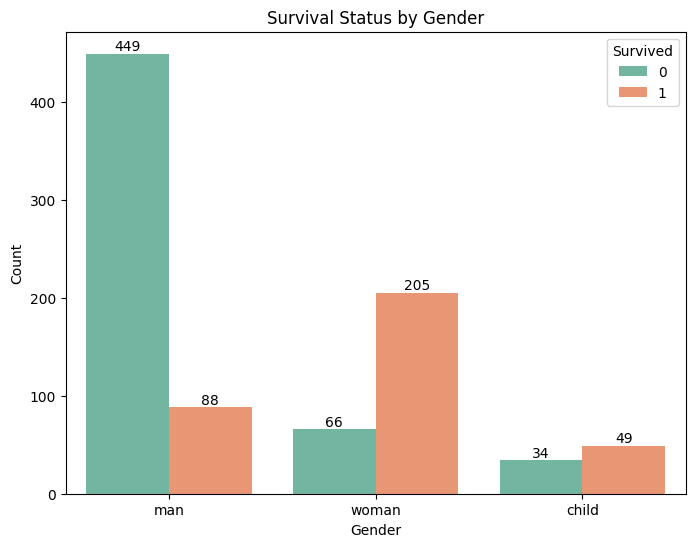

In [67]:
plt.figure(figsize=(8,6))

ax = sns.countplot(x='who',hue='survived',data=data,palette='Set2')

plt.title('Survival Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.legend(title='Survived')  # 0 = Dead, 1 = Alive
plt.show()


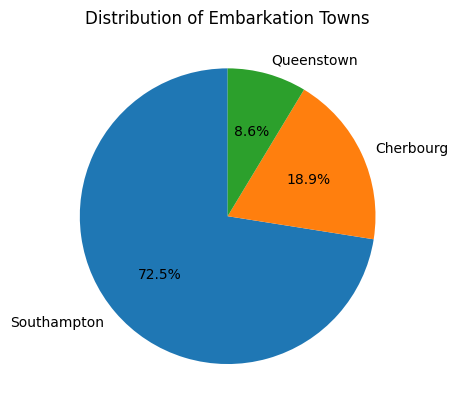

In [80]:
plt.Figure(figsize=(10,6))
plt.pie(data['embark_town'].value_counts(),labels=data['embark_town'].value_counts().index,autopct='%1.1f%%',startangle=90)
plt.title("Distribution of Embarkation Towns")
plt.show()

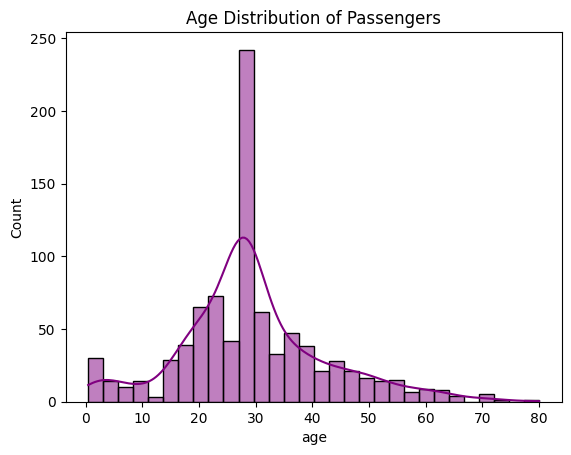

In [84]:
plt.Figure(figsize=(10,6))
sns.histplot(data['age'],bins=30,kde=True,color='purple')
plt.title("Age Distribution of Passengers")
plt.show()

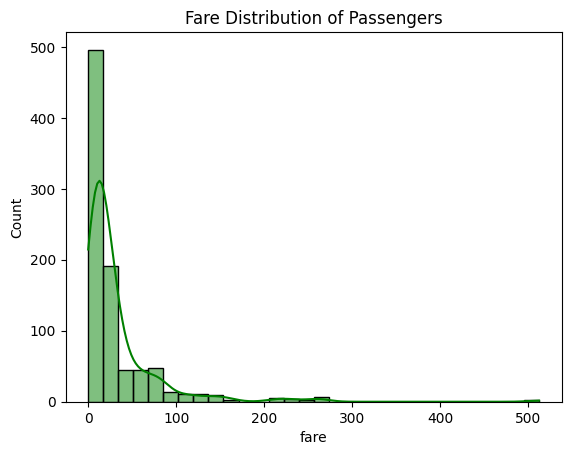

In [86]:
plt.Figure(figsize=(10,6))
sns.histplot(data['fare'],bins=30,kde=True,color='green')
plt.title("Fare Distribution of Passengers")
plt.show()

C:\Users\solan\AppData\Local\Temp\ipykernel_9584\1345901136.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.countplot(x='sibsp',data=data,palette='Set1')


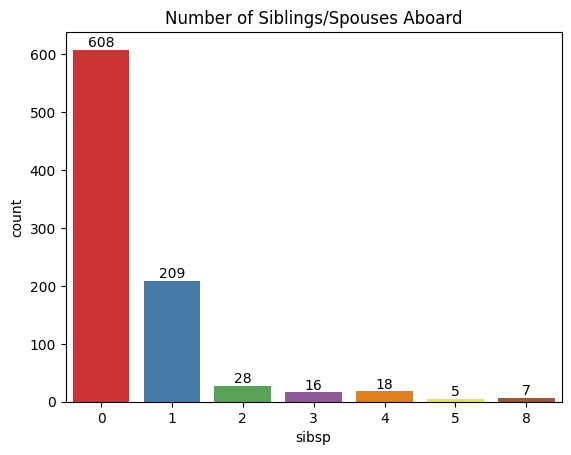

In [90]:
plt.Figure(figsize=(10,6))
a = sns.countplot(x='sibsp',data=data,palette='Set1')
for count in a.containers:
    a.bar_label(count)
plt.title("Number of Siblings/Spouses Aboard")
plt.show()

C:\Users\solan\AppData\Local\Temp\ipykernel_9584\1572565754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  m = sns.countplot(x='parch',data=data,palette='husl')


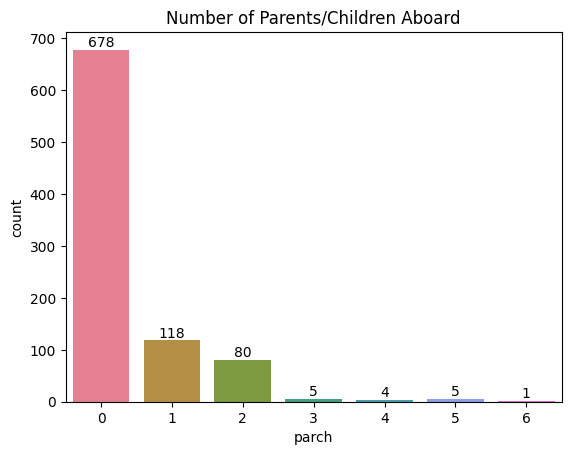

In [95]:
plt.Figure(figsize=(10,6))
m = sns.countplot(x='parch',data=data,palette='husl')
for count in m.containers:
    m.bar_label(count)
plt.title("Number of Parents/Children Aboard")
plt.show()